In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 87.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=577710c23be1a9c9024631670c0ae3bb2e536f6d6c076eddbd3591edb8168791
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


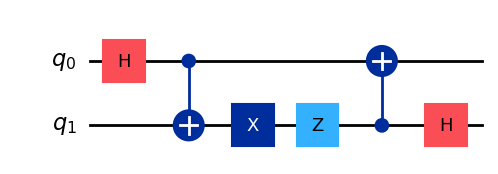

In [2]:
# Superdense coding

# The classical 2-bit value is encoded by applying X and/or Z gates

sdc = QuantumCircuit(2)

# qubits 0 and 1 are the shared entangled state
# Alice has qubit 1, Bob has qubit 0

# Entangle qubits 0 and 1
sdc.h(0)
sdc.cx(0,1)

# Encoding by Alice, working on qubit 1
# For each of 00, 01, 10, 11, there is a block of code that can be commented or uncommented.

# For 00, do nothing

# For 01, apply X to qubit 1
#sdc.x(1)

# For 10, apply Z to qubit 1
#sdc.z(1)

# For 11, apply X then Z to qubit 1
sdc.x(1)
sdc.z(1)

# Decoding by Bob, working on qubits 0 and 1

sdc.cx(1,0)
sdc.h(1)

sdc.draw("mpl")

In [3]:
state = Statevector.from_int(0, 4)  # 4 basis states on 2 qubits

# Apply the circuit to the state
state = state.evolve(sdc)

# Display using latex.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

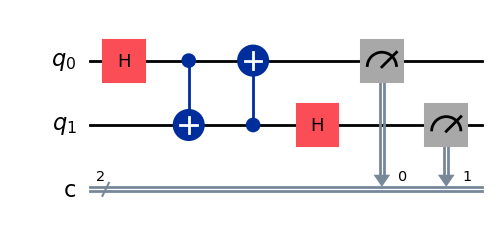

Alice encoded: 00


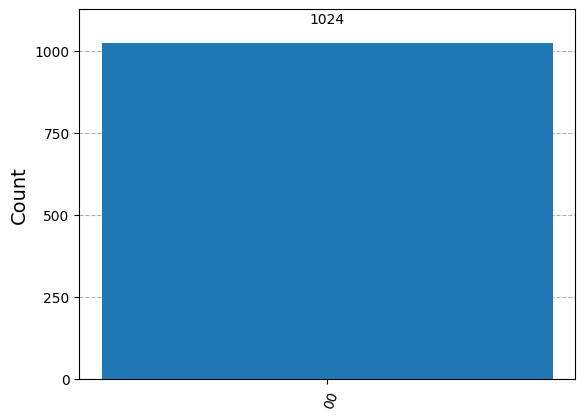

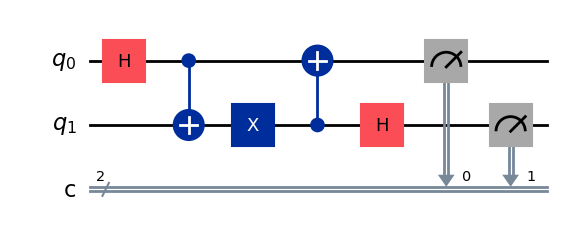

Alice encoded: 01


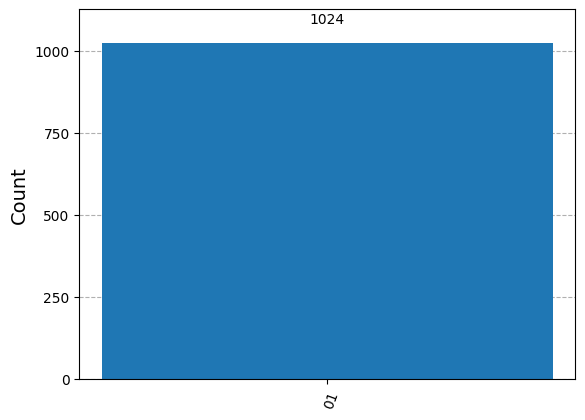

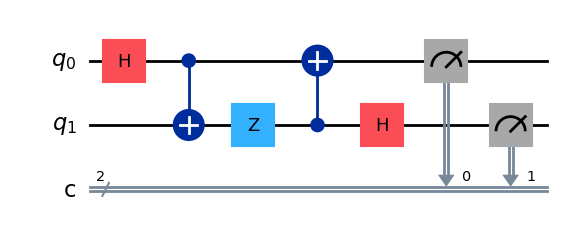

Alice encoded: 10


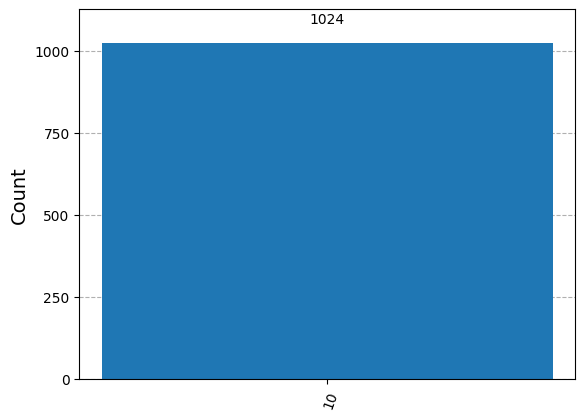

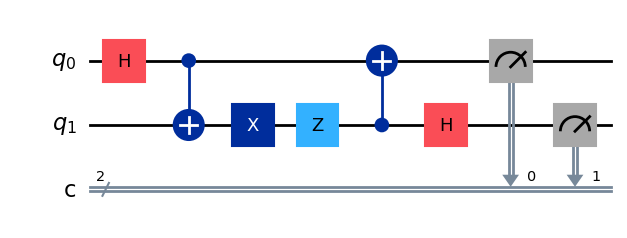

Alice encoded: 11


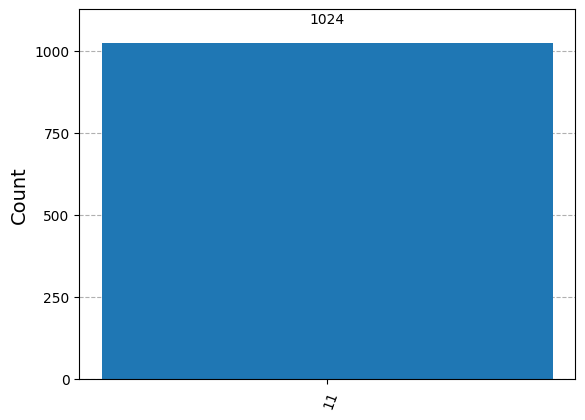

In [4]:
# EXERCISE

# Instead of calculating the state and displaying it, try simulating the circuit
# in a similar way to previous exercises. You will need to add some measurements
# so that you can check that the measurement statistics match the value that Alice
# encoded.

def simulate_sdc(bits, apply_gates):
    """
    bits: string label e.g. "00", "01", "10", "11"
    apply_gates: function that adds Alice's encoding gates to the circuit
    """
    sdc = QuantumCircuit(2, 2)  # added 2 classical bits for measurement

    # Entangle qubits 0 and 1
    sdc.h(0)
    sdc.cx(0, 1)

    # Alice's encoding (passed in as a function so we can swap easily)
    apply_gates(sdc)

    # Bob's decoding
    sdc.cx(1, 0)
    sdc.h(1)

    # added measurements
    sdc.measure([0, 1], [0, 1])

    display(sdc.draw("mpl"))

    # Simulate
    backend = BasicSimulator()
    qc_compiled = transpile(sdc, backend)
    job_sim = backend.run(qc_compiled, shots=1024)
    counts = job_sim.result().get_counts(qc_compiled)

    print(f"Alice encoded: {bits}")
    display(plot_histogram(counts))


# --- 00: do nothing ---
simulate_sdc("00", lambda sdc: None)

# --- 01: apply X ---
simulate_sdc("01", lambda sdc: sdc.x(1))

# --- 10: apply Z ---
simulate_sdc("10", lambda sdc: sdc.z(1))

# --- 11: apply X then Z ---
simulate_sdc("11", lambda sdc: [sdc.x(1), sdc.z(1)])

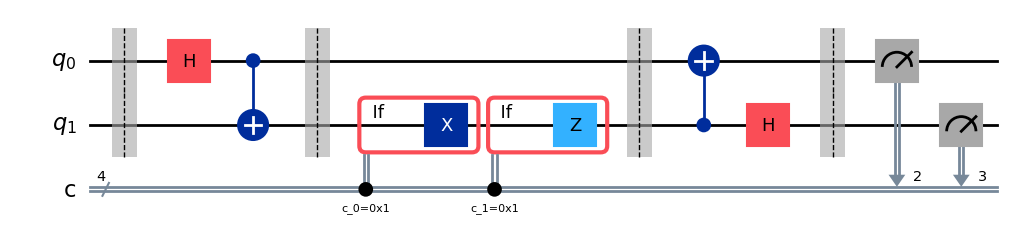

Alice encoded: 00


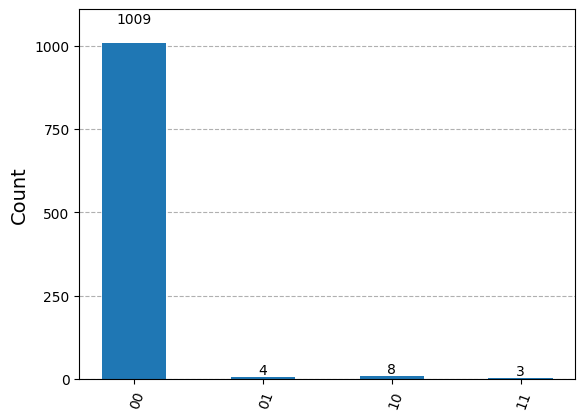

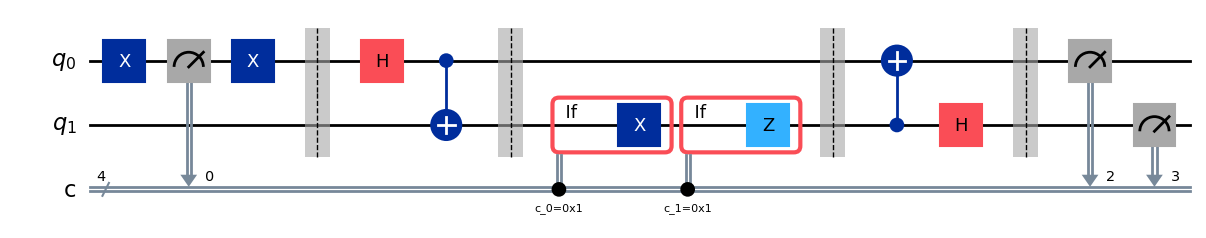

Alice encoded: 01


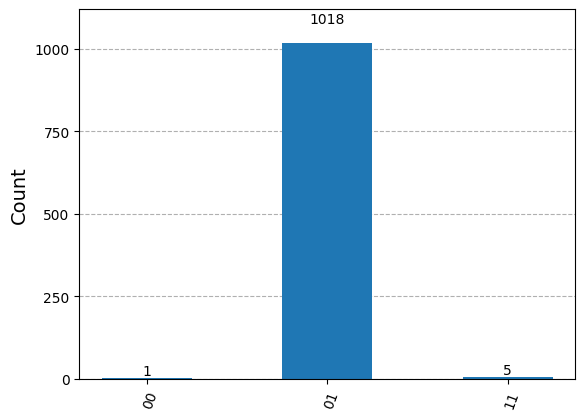

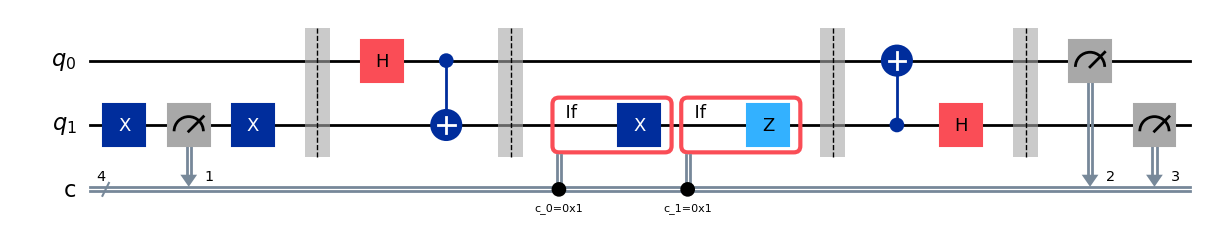

Alice encoded: 10


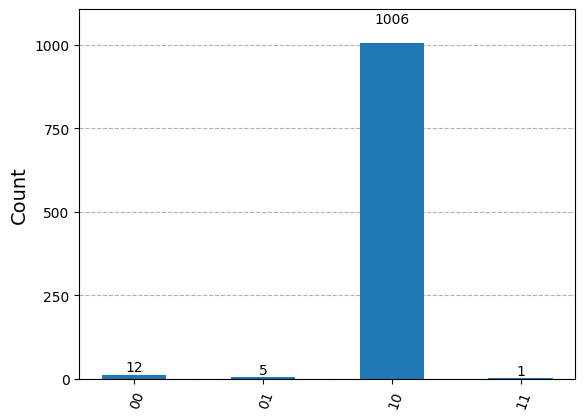

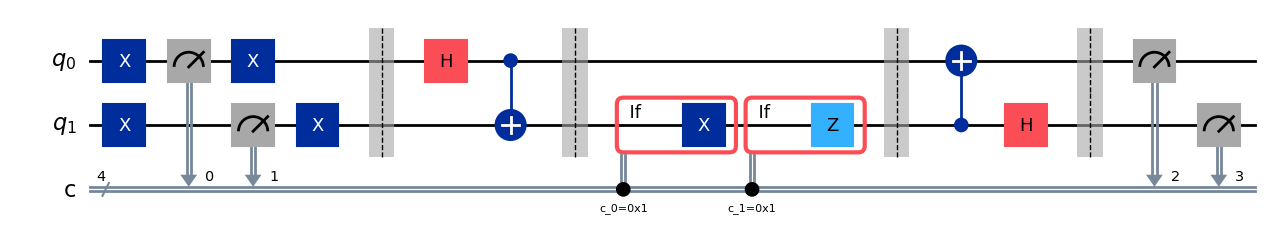

Alice encoded: 11


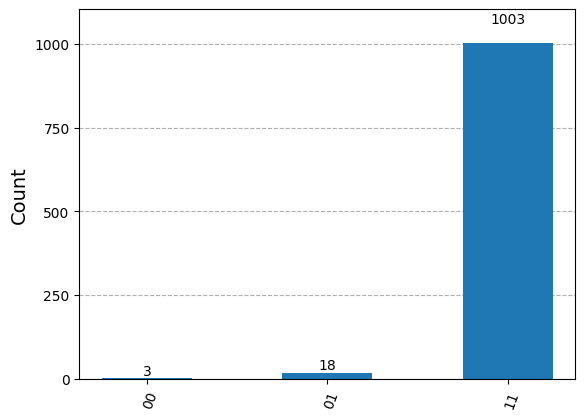

In [6]:
# EXERCISE

# A better implementation of superdense coding uses two classical bits as inputs,
# and the conditional operators that we saw in Lab-2B. Encoding the two-bit
# classical value is similar to the last stage of teleportation, where the measurement
# results are used to adjust Bob's qubit.

# Implement superdense coding this way.

from qiskit.providers.fake_provider import GenericBackendV2

def simulate_sdc_conditional(bit0, bit1):
    """
    bit0, bit1: classical bit values (0 or 1) representing Alice's 2-bit message
    Uses if_test for conditional gates, similar to teleportation in Lab-2B
    """
    # 4 classical bits total
    # bits 0,1 = Alice's input message
    # bits 2,3 = Bob's measurement results
    sdc = QuantumCircuit(2, 4)

    # Step 1: Load Alice's classical bits into the circuit
    # CHANGED: use classical input bits to control encoding
    # set classical bits 0 and 1 to represent Alice's message
    if bit0:
        sdc.x(0)          # flip to set classical bit 0
        sdc.measure(0, 0) # store in classical bit 0
        sdc.x(0)          # flip back so qubit 0 is |0> again

    if bit1:
        sdc.x(1)
        sdc.measure(1, 1)
        sdc.x(1)

    sdc.barrier()

    # Step 2: Entangle qubits 0 and 1
    sdc.h(0)
    sdc.cx(0, 1)

    sdc.barrier()

    # Step 3: Alice's encoding using if_test
    # similar to teleportation corrections in Lab-2B
    with sdc.if_test((0, 1)):  # if classical bit 0 is 1, apply X
        sdc.x(1)
    with sdc.if_test((1, 1)):  # if classical bit 1 is 1, apply Z
        sdc.z(1)

    sdc.barrier()

    # Step 4: Bob's decoding
    sdc.cx(1, 0)
    sdc.h(1)

    sdc.barrier()

    # Step 5: Measure (*storing in bits 2 and 3)
    sdc.measure([0, 1], [2, 3])

    display(sdc.draw("mpl"))

    # *need GenericBackendV2 for if_test support, same as teleportation
    backend = GenericBackendV2(num_qubits=2, control_flow=True)
    compiled = transpile(sdc, backend)
    job_sim = backend.run(compiled, shots=1024)
    counts = job_sim.result().get_counts(compiled)

    # Only look at Bob's measurement bits (bits 2 and 3)
    mcounts = marginal_counts(counts, indices=[2, 3])
    print(f"Alice encoded: {bit1}{bit0}")
    display(plot_histogram(mcounts))


# --- Try all 4 combinations ---
simulate_sdc_conditional(0, 0)  # 00
simulate_sdc_conditional(1, 0)  # 01
simulate_sdc_conditional(0, 1)  # 10
simulate_sdc_conditional(1, 1)  # 11